# Dataset 3 Analysis

First 5 rows:
   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumption family_history  \
0                        No            Yes            Moderate             No   
1                       Yes            Yes            Moderate            Yes   
2                       Yes            Yes                None             No   
3                       Yes             No            Moderate             No   
4                        No            Yes                None            Yes   

  lung_cancer  
0          No  
1         Yes  


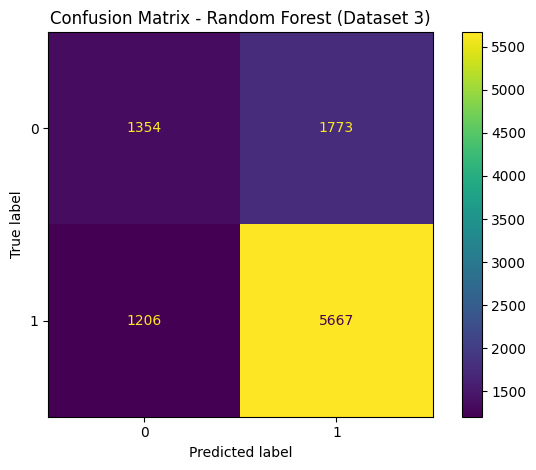


Random Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.7024
Mean Precision: 0.7582
Mean Recall   : 0.8324
Mean F1-score : 0.7936

Feature Importance Ranking
                     Feature  Importance
0                 pack_years    0.482203
1                        age    0.305177
2             radon_exposure    0.044425
3        alcohol_consumption    0.041223
4          asbestos_exposure    0.032274
5             copd_diagnosis    0.031799
6                     gender    0.021988
7             family_history    0.021084
8  secondhand_smoke_exposure    0.019828


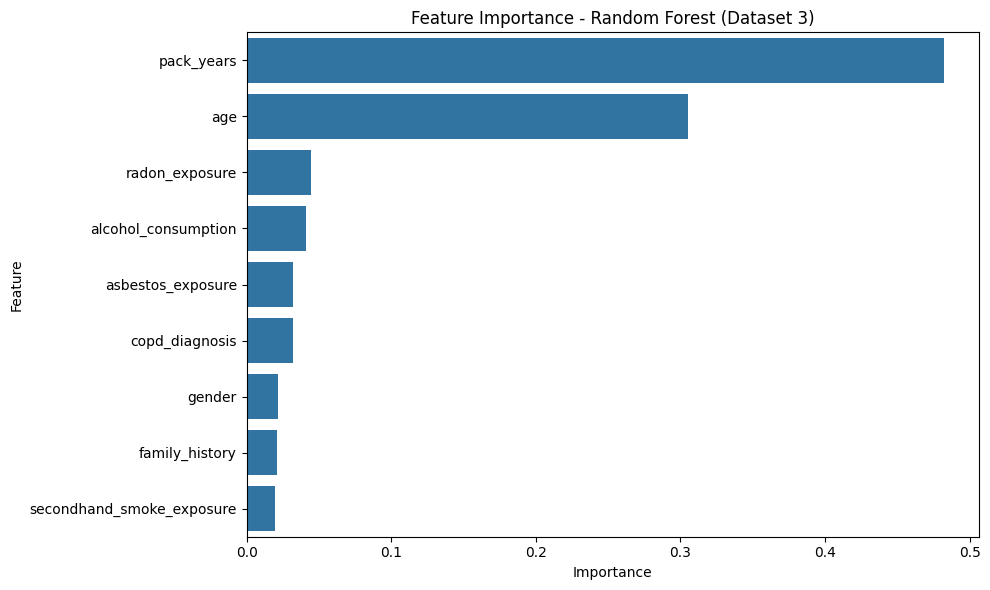


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 pack_years             1   0.61264   0.718176  0.718223   
1                        age             1   0.60398   0.743148  0.647625   
2                     gender             1   0.53286   0.682118  0.597803   
3             copd_diagnosis             1   0.57168   0.758276  0.553108   
4          asbestos_exposure             1   0.57182   0.760670  0.550052   
5             family_history             1   0.54942   0.736869  0.535706   
6  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
7             radon_exposure             1   0.49698   0.776887  0.376149   
8        alcohol_consumption             1   0.45400   0.710689  0.346671   

   F1-score  
0  0.718195  
1  0.692101  
2  0.622719  
3  0.639627  
4  0.638434  
5  0.620373  
6  0.617544  
7  0.506861  
8  0.466012  

Top-k Feature Combination Results (5-Fold CV)
  

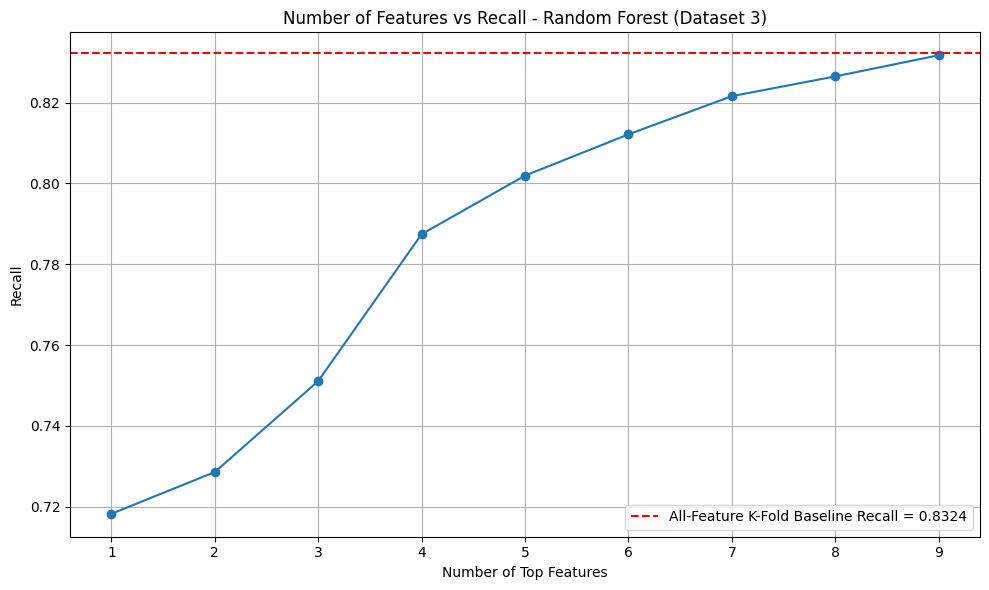

In [ ]:
# DATASET 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# LOAD DATASET
df3 = pd.read_csv(
    "Lung-Cancer-Risk-Dataset.csv",
    keep_default_na=False,
    na_values=["", " ", "NA", "N/A", "NaN", "nan", "NULL"]
)

# Clean column names
df3.columns = df3.columns.str.strip()

print("First 5 rows:")
print(df3.head())

print("\nColumn names:")
print(df3.columns.tolist())

print("\nDataset info:")
df3.info()

print("\nMissing values:")
print(df3.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df3.columns:
    df3 = df3.drop(columns=["patient_id"])

# FILL MISSING VALUES
for col in df3.columns:
    if df3[col].dtype == "object":
        df3[col] = df3[col].fillna(df3[col].mode()[0])
    else:
        df3[col] = df3[col].fillna(df3[col].median())

print("\nMissing values after filling:")
print(df3.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df3.columns:
    if df3[col].dtype == "object":
        le = LabelEncoder()
        df3[col] = le.fit_transform(df3[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "lung_cancer"
X3 = df3.drop(columns=[target_col])
y3 = df3[target_col]

print("\nClass distribution:")
print(y3.value_counts())

print("\nClass distribution (proportion):")
print(y3.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X3_train, y3_train)
y3_pred = rf_model_split.predict(X3_test)

accuracy_3 = accuracy_score(y3_test, y3_pred)
precision_3 = precision_score(y3_test, y3_pred, zero_division=0)
recall_3 = recall_score(y3_test, y3_pred, zero_division=0)
f1_3 = f1_score(y3_test, y3_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 3 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall   : {recall_3:.4f}")
print(f"F1-score : {f1_3:.4f}")

cm3 = confusion_matrix(y3_test, y3_pred)

print("\nConfusion Matrix:")
print(cm3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 3)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X3, y3)

feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()